In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
import xarray as xr
from dataclasses import dataclass
from collections import defaultdict
from pathlib import Path
from scipy.spatial import cKDTree
from typing import Dict, List, Tuple
import zarr


In [2]:
import torch, time

torch.cuda.synchronize(); t0 = time.perf_counter()
# imputer / normalizer (preprocessing)
torch.cuda.synchronize(); t1 = time.perf_counter()
# forward pass
torch.cuda.synchronize(); t2 = time.perf_counter()
# loss
torch.cuda.synchronize(); t3 = time.perf_counter()
# backward
torch.cuda.synchronize(); t4 = time.perf_counter()
print(f"pre={t1-t0:.3f} fwd={t2-t1:.3f} loss={t3-t2:.3f} bwd={t4-t3:.3f}")

pre=0.000 fwd=0.000 loss=0.000 bwd=0.000


## Fill NaNs with Power

In [2]:
# Cell 2 — Paths and config
SOURCE_ZARR   = Path("/mnt/weatherloss/WindPower/data/EGU26/cerra_EGULarge_xy.zarr")
OUT_ZARR      = Path("/mnt/weatherloss/WindPower/data/EGU26/filledpower.zarr")

METADATA_PATH = Path("/mnt/weatherloss/WindPower/data/NorthSea/Power/windfarm_metadata.csv")
COUNTS_PATH   = Path("/mnt/weatherloss/WindPower/data/NorthSea/Power/wind_farm_turbine_counts.csv")
SPECS_PATH    = Path("/mnt/weatherloss/WindPower/data/NorthSea/Power/turbine_specs.csv")

MAX_SNAP_KM = 4.0

In [3]:

@dataclass(frozen=True)
class TurbineSpec:
    cut_in:      float
    rated_ws:    float
    cut_out:     float
    rated_power: float  # MW per turbine


def power_curve(ws: np.ndarray, spec: TurbineSpec) -> np.ndarray:
    ws  = np.asarray(ws, dtype=float)
    out = np.zeros_like(ws, dtype=np.float32)

    denom = spec.rated_ws**3 - spec.cut_in**3
    a     = 1.0 / denom
    b     = spec.cut_in**3 / denom

    ramp = (ws >= spec.cut_in) & (ws < spec.rated_ws)
    out[ramp] = spec.rated_power * (a * ws[ramp]**3 - b)

    rated = (ws >= spec.rated_ws) & (ws < spec.cut_out)
    out[rated] = spec.rated_power

    return out


def load_specs(path: Path) -> Dict[str, TurbineSpec]:
    df = pd.read_csv(path)
    return {
        row["turbine_type (name-capacity-type)"]: TurbineSpec(
            cut_in      = float(row["cut_in_ms"]),
            rated_ws    = float(row["rated_ws_ms"]),
            cut_out     = float(row["cut_out_ms"]),
            rated_power = float(row["rated_power_mw"]),
        )
        for _, row in df.iterrows()
    }

In [4]:
# Cell 4 — Snap every farm to the nearest CERRA (y, x) cell,
# with manual overrides for farms that land on the wrong side
# of a cell boundary (verified against turbinemask).

# Correction map: farm name → (correct_y, correct_x)
# These 6 farms were off by 1 cell due to floating-point tie-breaking.
SNAP_OVERRIDES = {
    "Norther Offshore WP":  (113, 201),
    "BurboBank":             (161, 130),
    "BurboBankExtension":    (161, 130),
    "HumberGateway":         (159, 172),
    "RaceBank":              (150, 177),
    "Walney1":               (172, 127),
    "Walney2":               (172, 127),
}


def latlon_to_xy_km(lon, lat):
    """Flat-Earth projection to km — good enough for snapping over the North Sea."""
    R    = 6371.0
    lat0 = np.deg2rad(np.mean(lat))
    x_km = R * np.deg2rad(np.asarray(lon)) * np.cos(lat0)
    y_km = R * np.deg2rad(np.asarray(lat))
    return np.column_stack([x_km, y_km])


def snap_farms_to_cerra(
    meta:      pd.DataFrame,
    cerra_lat: np.ndarray,
    cerra_lon: np.ndarray,
    max_km:    float,
) -> pd.DataFrame:
    flat_lat = cerra_lat.ravel()
    flat_lon = cerra_lon.ravel()
    grid_pts = latlon_to_xy_km(flat_lon, flat_lat)
    farm_pts = latlon_to_xy_km(meta["lon"].values, meta["lat"].values)

    tree      = cKDTree(grid_pts)
    dist, idx = tree.query(farm_pts, k=1)

    ny, nx = cerra_lat.shape
    snap_y = idx // nx
    snap_x = idx %  nx

    bad = dist > max_km
    if bad.any():
        for i in np.where(bad)[0]:
            print(f"  WARNING: {meta.iloc[i]['farm']} is {dist[i]:.2f} km from nearest CERRA cell")
        raise ValueError(f"{bad.sum()} farm(s) exceed max snap distance {max_km} km")

    meta = meta.copy()
    meta["snap_y"]       = snap_y
    meta["snap_x"]       = snap_x
    meta["snap_dist_km"] = dist

    # Apply manual overrides
    n_overridden = 0
    for i, row in meta.iterrows():
        if row["farm"] in SNAP_OVERRIDES:
            old = (int(meta.at[i, "snap_y"]), int(meta.at[i, "snap_x"]))
            new = SNAP_OVERRIDES[row["farm"]]
            meta.at[i, "snap_y"] = new[0]
            meta.at[i, "snap_x"] = new[1]
            print(f"  Override: {row['farm']:30s} {old} → {new}")
            n_overridden += 1
    print(f"  {n_overridden} farms overridden.")

    return meta

# --- Run it ---
ds = xr.open_zarr(SOURCE_ZARR, consolidated=False)

meta = pd.read_csv(METADATA_PATH)
meta = snap_farms_to_cerra(
    meta,
    cerra_lat = ds["latitude"].values,
    cerra_lon = ds["longitude"].values,
    max_km    = 4.5,
)

print()
print(meta[["farm", "lat", "lon", "snap_y", "snap_x", "snap_dist_km"]].to_string())

  Override: Norther Offshore WP            (113, 202) → (113, 201)
  Override: BurboBank                      (161, 129) → (161, 130)
  Override: BurboBankExtension             (161, 129) → (161, 130)
  Override: HumberGateway                  (158, 172) → (159, 172)
  Override: RaceBank                       (150, 178) → (150, 177)
  Override: Walney1                        (173, 127) → (172, 127)
  Override: Walney2                        (173, 127) → (172, 127)
  7 farms overridden.

                                farm        lat       lon  snap_y  snap_x  snap_dist_km
0                    Belwind Phase 1  51.669541  2.802245     116     199      0.421705
1   Thorntonbank - C-Power - Area NE  51.563432  2.985691     114     201      2.060849
2   Thorntonbank - C-Power - Area SW  51.539986  2.921944     113     200      2.704776
3                Mermaid Offshore WP  51.717412  2.737938     117     198      1.803602
4        Nobelwind Offshore Windpark  51.661386  2.821048     116   

In [5]:
# Cell 5 — Build per-(y,x) turbine count matrix
# and verify it matches the turbinemask cells exactly.

counts_df = pd.read_csv(COUNTS_PATH).set_index("farm")
type_cols = [c for c in counts_df.columns if c.lower() != "total"]

# Accumulate turbine counts per CERRA cell, summing farms that share a cell
cell_counts: Dict[Tuple[int,int], Dict[str, float]] = defaultdict(lambda: defaultdict(float))

for _, row in meta.iterrows():
    farm = row["farm"]
    cell = (int(row["snap_y"]), int(row["snap_x"]))
    if farm not in counts_df.index:
        raise ValueError(f"Farm '{farm}' not found in counts file")
    for tcol in type_cols:
        n = float(counts_df.at[farm, tcol])
        if n > 0:
            cell_counts[cell][tcol] += n

# Ordered list of unique farm cells (from metadata snapping)
farm_cells: List[Tuple[int,int]] = list(cell_counts.keys())

# Build count matrix: shape (n_cells, n_turbine_types)
counts_matrix = np.zeros((len(farm_cells), len(type_cols)), dtype=np.float32)
for ci, cell in enumerate(farm_cells):
    for tj, tcol in enumerate(type_cols):
        counts_matrix[ci, tj] = cell_counts[cell].get(tcol, 0.0)

# --- Cross-check against turbinemask ---
turbinemask = ds["turbinemask"].values   # (y, x), 1.0 at farms, NaN elsewhere
mask_yx = set(zip(*np.where(~np.isnan(turbinemask))))   # set of (y, x) tuples
meta_yx = set(farm_cells)

only_in_mask = mask_yx - meta_yx
only_in_meta = meta_yx - mask_yx

if only_in_mask:
    print(f"WARNING — cells in turbinemask but NOT in metadata: {only_in_mask}")
if only_in_meta:
    print(f"WARNING — cells in metadata but NOT in turbinemask: {only_in_meta}")
if not only_in_mask and not only_in_meta:
    print(f"OK — {len(farm_cells)} farm cells match turbinemask exactly.")

print(f"\nTurbine types: {type_cols}")
print(f"counts_matrix shape: {counts_matrix.shape}")


OK — 27 farm cells match turbinemask exactly.

Turbine types: ['AlstomHaliade-6-150', 'MHIVestas-8.4-V164', 'MHIVestas-9.5-V164', 'MHIVestas-8.25-V164', 'Repower-5', 'Repower-6.15-M126', 'SiemensGamesaSG-8.4-167DD', 'SiemensSG-8.0-167DD', 'SiemensSWT-3.6-107', 'SiemensSWT-3.6-120', 'SiemensSWT-6.0-120', 'SiemensSWT-6.0-154', 'SiemensSWT-7.0-154', 'SiemensSWT-7.35-154', 'Vestas-3.0-V112', 'Vestas-3.3-V112', 'Vestas-3.4-V112', 'Vestas-8-V164', 'Vestas-9.5-V164', 'Vestas-3-V90']
counts_matrix shape: (27, 20)


In [6]:
# Cell 6 — Fill NaNs with power-curve estimates and write filledpower.zarr

specs = load_specs(SPECS_PATH)

# Load the full power array  (time, y, x) — this fits in RAM for float32
# If memory is tight, switch to the chunked loop below instead.
print("Loading power ...")
power = ds["power"].values.copy()   # float32, NaN at non-farm cells
print(f"  shape: {power.shape},  dtype: {power.dtype}")

print("Loading ws100 ...")
ws100 = ds["ws100"].values             # float32 (time, y, x)
print(f"  shape: {ws100.shape}")

ntime = power.shape[0]
n_filled_total = 0

for ci, (cy, cx) in enumerate(farm_cells):
    ws_cell    = ws100[:, cy, cx]           # (time,)
    power_cell = power[:, cy, cx]           # (time,)  — may contain NaNs

    # Compute synthetic power: sum over all turbine types at this cell
    synthetic = np.zeros(ntime, dtype=np.float32)
    for tj, tname in enumerate(type_cols):
        n_turbines = counts_matrix[ci, tj]
        if n_turbines > 0:
            synthetic += power_curve(ws_cell, specs[tname]) * n_turbines

    # Fill only the NaN timesteps
    missing        = np.isnan(power_cell)
    n_filled       = int(missing.sum())
    n_filled_total += n_filled
    power[missing, cy, cx] = synthetic[missing]

    print(f"  Cell ({cy:3d},{cx:3d}): {n_filled:5d}/{ntime} timesteps filled with synthetic")

print(f"\nTotal timesteps filled across all cells: {n_filled_total}")

# Sanity: no NaNs should remain at farm cells
for cy, cx in farm_cells:
    remaining = int(np.isnan(power[:, cy, cx]).sum())
    if remaining:
        print(f"  ERROR: ({cy},{cx}) still has {remaining} NaNs after fill")
print("Sanity check passed — no NaNs remain at farm cells.")

# --- Build output Dataset ---
# Load lat/lon as plain numpy arrays to strip any zarr chunk encoding.
lat_np = ds["latitude"].values   # (y, x) numpy array, no encoding
lon_np = ds["longitude"].values  # (y, x) numpy array, no encoding

ds_out = xr.Dataset(
    {
        "power": xr.DataArray(
            power,
            dims   = ["time", "y", "x"],
            coords = {
                "time":      ds["time"].values,
                "latitude":  (["y", "x"], lat_np),
                "longitude": (["y", "x"], lon_np),
            },
            attrs = {"units": "MW", "long_name": "Wind farm power (obs + power-curve fill)"},
        )
    }
)

# Match source chunking for the power variable only
src_chunks = ds["power"].encoding.get("chunks") or ds["power"].chunks
print(f"Source chunks: {src_chunks}")

if src_chunks:
    ds_out = ds_out.chunk({"time": src_chunks[0], "y": src_chunks[1], "x": src_chunks[2]})

# Encoding for power only — coordinates are plain numpy, no encoding needed
encoding = {
    "power": {"chunks": src_chunks, "dtype": "float32"}
} if src_chunks else {}

# Write
print(f"\nWriting to {OUT_ZARR} ...")
ds_out.to_zarr(OUT_ZARR, mode="w", consolidated=True, encoding=encoding)
print("Done.")


Loading power ...


  shape: (31408, 308, 293),  dtype: float32
Loading ws100 ...
  shape: (31408, 308, 293)
  Cell (116,199): 15096/31408 timesteps filled with synthetic
  Cell (114,201): 15103/31408 timesteps filled with synthetic
  Cell (113,200): 15096/31408 timesteps filled with synthetic
  Cell (117,198): 16554/31408 timesteps filled with synthetic
  Cell (113,201): 15103/31408 timesteps filled with synthetic
  Cell (116,198): 15184/31408 timesteps filled with synthetic
  Cell (115,200): 17108/31408 timesteps filled with synthetic
  Cell (171,130): 25568/31408 timesteps filled with synthetic
  Cell (161,130): 21200/31408 timesteps filled with synthetic
  Cell (149,184): 19728/31408 timesteps filled with synthetic
  Cell (128,196): 25568/31408 timesteps filled with synthetic
  Cell (119,179): 22648/31408 timesteps filled with synthetic
  Cell (122,188): 19728/31408 timesteps filled with synthetic
  Cell (161,125): 22648/31408 timesteps filled with synthetic
  Cell (162,190): 28488/31408 timesteps fil

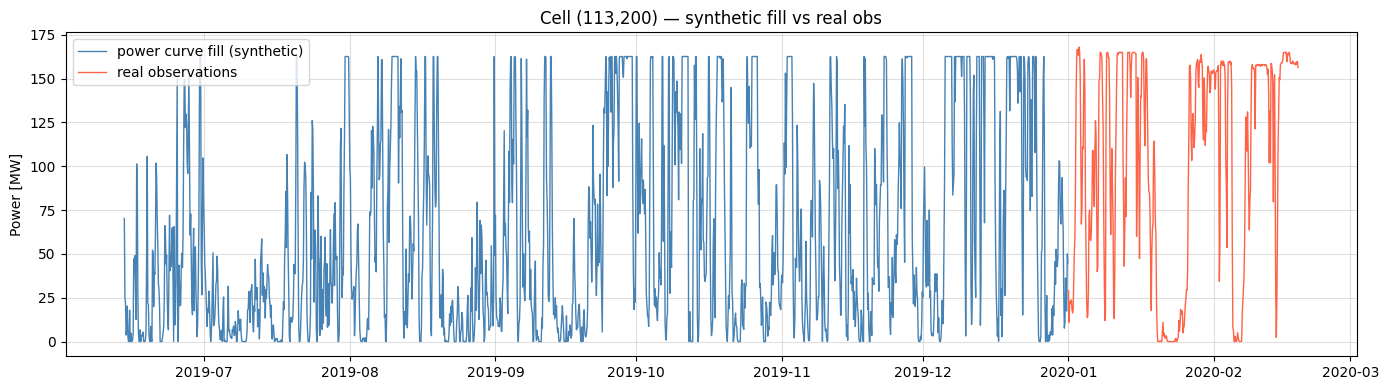

In [18]:

# Cell 7 — Quick verification: spot-check one farm cell (memory-safe)
import matplotlib.pyplot as plt

# # Free the large arrays from Cell 6 before loading anything new
# del power, ws100

cy, cx = farm_cells[2]

# Open both zarrs lazily — no .values yet
ds_src    = xr.open_zarr(SOURCE_ZARR, consolidated=False)
ds_filled = xr.open_zarr(OUT_ZARR,    consolidated=True)

# Load only the single (time,) slice for this cell
real_power = ds_src["power"].isel(y=cy, x=cx).values   # (time,)
fill_power = ds_filled["power"].isel(y=cy, x=cx).values  # (time,)
times      = ds_src["time"].values


# Separate the filled series into synthetic-only and real-only
was_nan    = np.isnan(real_power)   # True where original was NaN → power curve was used

synthetic_only = fill_power.copy()
synthetic_only[~was_nan] = np.nan   # mask out timesteps where real obs existed

sl = slice(13000, 15000)
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(times[sl], synthetic_only[sl], color="steelblue", lw=1,
        label="power curve fill (synthetic)")
ax.plot(times[sl], real_power[sl], color="tomato", lw=1,
        label="real observations")

ax.set_title(f"Cell ({cy},{cx}) — synthetic fill vs real obs")
ax.set_ylabel("Power [MW]")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## Standardized Turbine

In [4]:
SOURCE_ZARR = Path("/mnt/weatherloss/WindPower/data/EGU26/cerra_EGULarge_xy.zarr")
OUT_ZARR    = Path("/mnt/weatherloss/WindPower/data/EGU26/synthetic_power.zarr")
SPECS_PATH  = Path("/mnt/weatherloss/WindPower/data/NorthSea/Power/turbine_specs.csv")

REAL_FARM_CELLS = [
    (113, 201),
    (161, 130),
    (159, 172),
    (150, 177),
    (172, 127),
    # add remaining real farm (y, x) pairs here if needed
]

FRACTION_SEA = 0.25
MIN_TURBINES = 20
MAX_TURBINES = 72

BELGIAN_FLEET = {
    "Vestas-3-V90":        55,
    "Vestas-3.3-V112":    122,
    "Repower-5":            6,
    "Repower-6.15-M126":   48,
    "SiemensSWT-7.0-154":  42,
    "SiemensSG-8.0-167DD": 48,
    "MHIVestas-8.4-V164":  44,
    "MHIVestas-9.5-V164":  23,
}

In [5]:
FRACTION_SEA = 0.25
MIN_TURBINES = 20
MAX_TURBINES = 72

BELGIAN_FLEET = {
    "Vestas-3-V90":        55,
    "Vestas-3.3-V112":    122,
    "Repower-5":            6,
    "Repower-6.15-M126":   48,
    "SiemensSWT-7.0-154":  42,
    "SiemensSG-8.0-167DD": 48,
    "MHIVestas-8.4-V164":  44,
    "MHIVestas-9.5-V164":  23,
}

In [6]:
@dataclass(frozen=True)
class TurbineSpec:
    cut_in:      float
    rated_ws:    float
    cut_out:     float
    rated_power: float   # MW per turbine


def load_specs(path: Path) -> Dict[str, TurbineSpec]:
    df = pd.read_csv(path)
    return {
        row["turbine_type (name-capacity-type)"]: TurbineSpec(
            cut_in      = float(row["cut_in_ms"]),
            rated_ws    = float(row["rated_ws_ms"]),
            cut_out     = float(row["cut_out_ms"]),
            rated_power = float(row["rated_power_mw"]),
        )
        for _, row in df.iterrows()
    }


def power_curve(ws: np.ndarray, spec: TurbineSpec) -> np.ndarray:
    ws  = np.asarray(ws, dtype=np.float64)
    out = np.zeros(len(ws), dtype=np.float32)
    denom = spec.rated_ws**3 - spec.cut_in**3
    a     = 1.0 / denom
    b     = spec.cut_in**3 / denom
    ramp  = (ws >= spec.cut_in) & (ws < spec.rated_ws)
    rated = (ws >= spec.rated_ws) & (ws < spec.cut_out)
    out[ramp]  = spec.rated_power * (a * ws[ramp]**3 - b)
    out[rated] = spec.rated_power
    return out

In [6]:
ds = xr.open_zarr(SOURCE_ZARR, consolidated=False)

lsm   = ds["lsm"].values
ntime = ds.sizes["time"]
ny    = ds.sizes["y"]
nx    = ds.sizes["x"]
print(f"Grid shape: time={ntime}, y={ny}, x={nx}")

# Pure-sea cells
sea_ys, sea_xs = np.where(lsm == 0.0)
sea_cells = list(zip(sea_ys.tolist(), sea_xs.tolist()))
print(f"Pure-sea cells (lsm == 0): {len(sea_cells)}")

# Exclude real farm cells
real_set  = set(REAL_FARM_CELLS)
sea_cells = [(y, x) for y, x in sea_cells if (y, x) not in real_set]
print(f"Sea cells after excluding {len(real_set)} real farms: {len(sea_cells)}")

# Sample 25%
n_select   = int(len(sea_cells) * FRACTION_SEA)
rng        = np.random.default_rng()
chosen_idx = rng.choice(len(sea_cells), size=n_select, replace=False)
chosen_cells = [sea_cells[i] for i in chosen_idx]
print(f"Selected synthetic cells: {n_select}  ({FRACTION_SEA * 100:.0f}% of sea)")

Grid shape: time=31408, y=308, x=293
Pure-sea cells (lsm == 0): 53131
Sea cells after excluding 5 real farms: 53126
Selected synthetic cells: 13281  (25% of sea)


In [7]:
turbine_names = list(BELGIAN_FLEET.keys())
fleet_counts  = np.array([BELGIAN_FLEET[t] for t in turbine_names], dtype=float)
weights       = fleet_counts / fleet_counts.sum()

assigned_types  = rng.choice(turbine_names, size=n_select, p=weights)
assigned_counts = rng.integers(MIN_TURBINES, MAX_TURBINES + 1, size=n_select)

# Quick summary
for tname, w in zip(turbine_names, weights):
    n_assigned = int((assigned_types == tname).sum())
    print(f"  {tname:25s}  weight={w:.3f}  assigned to {n_assigned} cells")

  Vestas-3-V90               weight=0.142  assigned to 1850 cells
  Vestas-3.3-V112            weight=0.314  assigned to 4157 cells
  Repower-5                  weight=0.015  assigned to 212 cells
  Repower-6.15-M126          weight=0.124  assigned to 1667 cells
  SiemensSWT-7.0-154         weight=0.108  assigned to 1487 cells
  SiemensSG-8.0-167DD        weight=0.124  assigned to 1621 cells
  MHIVestas-8.4-V164         weight=0.113  assigned to 1525 cells
  MHIVestas-9.5-V164         weight=0.059  assigned to 762 cells


In [8]:
specs = load_specs(SPECS_PATH)
for tname in turbine_names:
    if tname not in specs:
        raise KeyError(f"'{tname}' not found in specs file. Available: {list(specs.keys())}")
print(f"Specs loaded OK for {len(turbine_names)} turbine types.")

Specs loaded OK for 8 turbine types.


In [9]:
import zarr

src_chunks = ds["power"].encoding.get("chunks") or ds["power"].chunks
chunks = tuple(src_chunks) if src_chunks else (56, 128, 128)
print(f"Using chunks: {chunks}")

store = zarr.open(
    str(OUT_ZARR),
    mode="w",
    shape=(ntime, ny, nx),
    chunks=chunks,
    dtype="float32",
    fill_value=float("nan"),
)
print(f"Created zarr store at {OUT_ZARR}, shape={store.shape}")

Using chunks: (56, 128, 128)
Created zarr store at /mnt/weatherloss/WindPower/data/EGU26/synthetic_power.zarr, shape=(31408, 308, 293)


In [11]:
from collections import defaultdict

cells_by_y = defaultdict(list)
for i, (cy, cx) in enumerate(chosen_cells):
    cells_by_y[cy].append((i, cx))

TIME_CHUNK = 56
n_time_chunks = int(np.ceil(ntime / TIME_CHUNK))

print(f"Processing {n_time_chunks} time chunks ...")

for tc in range(n_time_chunks):
    t0 = tc * TIME_CHUNK
    t1 = min(t0 + TIME_CHUNK, ntime)
    chunk_len = t1 - t0

    if tc % 20 == 0:
        print(f"  chunk {tc}/{n_time_chunks}  (t={t0}..{t1}) ...")

    # Read one time slice of ws100 — ~20 MB
    ws_slice = ds["ws100"][t0:t1, :, :].values  # (chunk_len, ny, nx)

    # Build output in RAM — same size, ~20 MB
    out_slice = np.full((chunk_len, ny, nx), np.nan, dtype=np.float32)

    for cy, cell_list in cells_by_y.items():
        for (i, cx) in cell_list:
            out_slice[:, cy, cx] = (
                power_curve(ws_slice[:, cy, cx], specs[assigned_types[i]])
                * int(assigned_counts[i])
            )

    # One single write for the entire time chunk
    store[t0:t1, :, :] = out_slice

print(f"Done — {n_select} cells written.")

Processing 561 time chunks ...
  chunk 0/561  (t=0..56) ...
  chunk 20/561  (t=1120..1176) ...
  chunk 40/561  (t=2240..2296) ...
  chunk 60/561  (t=3360..3416) ...
  chunk 80/561  (t=4480..4536) ...
  chunk 100/561  (t=5600..5656) ...
  chunk 120/561  (t=6720..6776) ...
  chunk 140/561  (t=7840..7896) ...
  chunk 160/561  (t=8960..9016) ...
  chunk 180/561  (t=10080..10136) ...
  chunk 200/561  (t=11200..11256) ...
  chunk 220/561  (t=12320..12376) ...
  chunk 240/561  (t=13440..13496) ...
  chunk 260/561  (t=14560..14616) ...
  chunk 280/561  (t=15680..15736) ...
  chunk 300/561  (t=16800..16856) ...
  chunk 320/561  (t=17920..17976) ...
  chunk 340/561  (t=19040..19096) ...
  chunk 360/561  (t=20160..20216) ...
  chunk 380/561  (t=21280..21336) ...
  chunk 400/561  (t=22400..22456) ...
  chunk 420/561  (t=23520..23576) ...
  chunk 440/561  (t=24640..24696) ...
  chunk 460/561  (t=25760..25816) ...
  chunk 480/561  (t=26880..26936) ...
  chunk 500/561  (t=28000..28056) ...
  chunk 52

In [11]:
ds = xr.open_zarr(SOURCE_ZARR, consolidated=False)

chunks = (56, 128, 128)

raw_dask = da.from_zarr(str(OUT_ZARR)).rechunk(chunks)

ds_out = xr.Dataset(
    {
        "synthetic_power": xr.DataArray(
            raw_dask,
            dims   = ["time", "y", "x"],
            coords = {
                "time":      ds["time"].values,
                "latitude":  (["y", "x"], ds["latitude"].values),
                "longitude": (["y", "x"], ds["longitude"].values),
            },
            attrs = {
                "units":                  "MW",
                "long_name":              "Synthetic wind farm power from power-curve projection",
                "fraction_sea_populated": FRACTION_SEA,
                "turbine_count_range":    f"{MIN_TURBINES}-{MAX_TURBINES}",
                "turbine_types":          ", ".join(turbine_names),
            },
        )
    }
)

encoding = {"synthetic_power": {"chunks": chunks, "dtype": "float32"}}

print(f"Writing to {OUT_ZARR_FINAL} ...")
ds_out.to_zarr(OUT_ZARR_FINAL, mode="w", consolidated=True, encoding=encoding)
print("Done.")

Writing to /mnt/weatherloss/WindPower/data/EGU26/synthetic_power_final.zarr ...
Done.


In [13]:
import zarr
import numpy as np
import xarray as xr

ds_check = xr.open_zarr(OUT_ZARR_FINAL, consolidated=True)
print(ds_check)
print()

sp = ds_check["synthetic_power"]

# 1. Shape and dtype
print(f"Shape:  {sp.shape}")
print(f"Dtype:  {sp.dtype}")
print()

# 2. Overall NaN structure
first_t = sp.isel(time=0).values
n_populated = int(np.sum(~np.isnan(first_t)))
n_nan       = int(np.sum(np.isnan(first_t)))
print(f"Timestep 0: {n_populated} populated cells, {n_nan} NaN cells")
print(f"  expected populated: ~{int(53126 * 0.25)}")
print()

# 3. All populated cells should be >= 0 (power can't be negative)
vals = sp.isel(time=0).values
populated_vals = vals[~np.isnan(vals)]
print(f"Populated cell values — min: {populated_vals.min():.2f}  max: {populated_vals.max():.2f}  mean: {populated_vals.mean():.2f} MW")
assert populated_vals.min() >= 0, "Negative power values found!"
print()

# 4. NaN structure is consistent across time (same cells populated at t=0 and t=100)
t100 = sp.isel(time=100).values
assert np.array_equal(np.isnan(first_t), np.isnan(t100)), "NaN mask differs between timesteps!"
print("NaN mask consistent across timesteps: OK")
print()

# 5. Coordinates look sensible
print(f"Time range:  {str(ds_check.time.values[0])[:16]} → {str(ds_check.time.values[-1])[:16]}")
print(f"Lat  range:  {float(ds_check.latitude.min()):.3f} → {float(ds_check.latitude.max()):.3f}")
print(f"Lon  range:  {float(ds_check.longitude.min()):.3f} → {float(ds_check.longitude.max()):.3f}")
print()

# 6. Spot-check: populated cells should all have lsm == 0 in source
ds_src = xr.open_zarr(SOURCE_ZARR, consolidated=False)
lsm = ds_src["lsm"].values
pop_ys, pop_xs = np.where(~np.isnan(first_t))
lsm_at_populated = lsm[pop_ys, pop_xs]
non_sea = (lsm_at_populated != 0.0).sum()
print(f"Populated cells with lsm != 0: {non_sea}  (should be 0)")
assert non_sea == 0, "Some synthetic cells are not pure-sea!"
print()

print("All checks passed.")

<xarray.Dataset> Size: 11GB
Dimensions:          (time: 31408, y: 308, x: 293)
Coordinates:
  * time             (time) datetime64[ns] 251kB 2015-01-01 ... 2025-09-30T21...
    latitude         (y, x) float64 722kB dask.array<chunksize=(154, 147), meta=np.ndarray>
    longitude        (y, x) float64 722kB dask.array<chunksize=(154, 147), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    synthetic_power  (time, y, x) float32 11GB dask.array<chunksize=(56, 128, 128), meta=np.ndarray>

Shape:  (31408, 308, 293)
Dtype:  float32

Timestep 0: 13281 populated cells, 76963 NaN cells
  expected populated: ~13281

Populated cell values — min: 0.00  max: 684.00  mean: 223.81 MW

NaN mask consistent across timesteps: OK

Time range:  2015-01-01T00:00 → 2025-09-30T21:00
Lat  range:  44.438 → 61.152
Lon  range:  -17.471 → 10.810

Populated cells with lsm != 0: 0  (should be 0)

All checks passed.


In [14]:
ds_check

<xarray.Dataset> Size: 11GB
Dimensions:          (time: 31408, y: 308, x: 293)
Coordinates:
  * time             (time) datetime64[ns] 251kB 2015-01-01 ... 2025-09-30T21...
    latitude         (y, x) float64 722kB dask.array<chunksize=(154, 147), meta=np.ndarray>
    longitude        (y, x) float64 722kB dask.array<chunksize=(154, 147), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    synthetic_power  (time, y, x) float32 11GB dask.array<chunksize=(56, 128, 128), meta=np.ndarray>

In [12]:
import xarray as xr
import numpy as np
from scipy.stats import binned_statistic_2d
from pathlib import Path

# --- CONFIGURATION ---
SOURCE_CERRA_SYNTH = Path("/mnt/weatherloss/WindPower/data/EGU26/synthetic_power_final.zarr")
SOURCE_ERA5        = Path("/mnt/weatherloss/WindPower/data/EGU26/era5_EGU_large2.zarr") # Path to your template ERA5
OUT_ZARR_ERA5_ONLY = Path("/mnt/weatherloss/WindPower/data/EGU26/era5_synthetic_only.zarr")

# 1. Load Datasets
ds_cerra = xr.open_zarr(SOURCE_CERRA_SYNTH, consolidated=False)
ds_era5  = xr.open_zarr(SOURCE_ERA5, consolidated=False)

# 2. Identify populated CERRA cells (where synthetic farms exist)
# We only process non-NaN cells to save massive amounts of RAM
first_ts = ds_cerra["synthetic_power"].isel(time=0).values
mask = ~np.isnan(first_ts)

lat_cerra = ds_cerra.latitude.values[mask]
lon_cerra = ds_cerra.longitude.values[mask]

# 3. Define Robust ERA5 Bin Edges (Midpoint method)
def get_edges_robust(centers):
    c = np.sort(centers)
    midpoints = (c[1:] + c[:-1]) / 2
    step = np.diff(c).mean()
    return np.concatenate(([c[0] - step/2], midpoints, [c[-1] + step/2]))

era5_lats_orig = ds_era5.latitude.values
era5_lons_orig = ds_era5.longitude.values

lat_edges = get_edges_robust(era5_lats_orig)
lon_edges = get_edges_robust(era5_lons_orig)

# 4. Map CERRA cells to ERA5 grid indices
ret = binned_statistic_2d(
    lat_cerra, lon_cerra, values=None, 
    statistic='count', 
    bins=[lat_edges, lon_edges]
)

# Decode bin numbers into 2D indices
bin_indices = ret.binnumber
n_lon_bins = len(lon_edges) - 1

# Scipy adds 2 to dimensions for underflow/overflow bins; adjust to 0-based
lat_idx_raw, lon_idx_raw = np.divmod(bin_indices, n_lon_bins + 2)
lat_idx = lat_idx_raw - 1
lon_idx = lon_idx_raw - 1

# Helper to map sorted bin index back to original ERA5 lat order (e.g., 66 -> 40)
lat_map = np.argsort(np.argsort(era5_lats_orig)) 
sorted_lat_indices = lat_map[lat_idx]

# 5. Iterative Aggregation (Time-Chunked)
ntime = ds_cerra.dims['time']
nlat  = len(era5_lats_orig)
nlon  = len(era5_lons_orig)

# Pre-allocate result array
era5_synth_power = np.zeros((ntime, nlat, nlon), dtype=np.float32)

CHUNK_SIZE = 1000
print(f"Aggregating {ntime} timesteps in chunks of {CHUNK_SIZE}...")

for t_idx in range(0, ntime, CHUNK_SIZE):
    t_end = min(t_idx + CHUNK_SIZE, ntime)
    
    # Extract only populated cells for this time chunk
    cerra_chunk = ds_cerra["synthetic_power"].isel(time=slice(t_idx, t_end)).values[:, mask]
    
    # Process each timestep in chunk
    for i, global_t in enumerate(range(t_idx, t_end)):
        # np.add.at handles multiple CERRA cells falling into one ERA5 cell
        np.add.at(era5_synth_power[global_t], (sorted_lat_indices, lon_idx), cerra_chunk[i])
    
    if t_idx % 5000 == 0:
        print(f"  Processed up to t={t_end}...")

# Post-processing: Convert zeros back to NaN for sparse representation
era5_synth_power[era5_synth_power == 0] = np.nan

# 6. Build Final Dataset and Save
ds_out = xr.Dataset(
    {
        "synthetic_power": (["time", "latitude", "longitude"], era5_synth_power)
    },
    coords={
        "time":      ds_cerra.time.values,
        "latitude":  era5_lats_orig,
        "longitude": era5_lons_orig
    }
)

ds_out["synthetic_power"].attrs = {
    "units": "MW",
    "long_name": "Synthetic wind power aggregated to ERA5 Grid",
    "description": "Summation of CERRA 5.5km synthetic farms within each 0.25° ERA5 cell"
}

print(f"Writing to {OUT_ZARR_ERA5_ONLY}...")
ds_out.to_zarr(OUT_ZARR_ERA5_ONLY, mode="w", consolidated=True)
print("Processing Complete.")

/tmp/ipykernel_2525752/3498764605.py:57: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ntime = ds_cerra.dims['time']


Aggregating 31408 timesteps in chunks of 1000...


  Processed up to t=1000...
  Processed up to t=6000...
  Processed up to t=11000...
  Processed up to t=16000...
  Processed up to t=21000...
  Processed up to t=26000...
  Processed up to t=31000...
Writing to /mnt/weatherloss/WindPower/data/EGU26/era5_synthetic_only.zarr...
Processing Complete.


In [14]:
# Count how many cells have power at the first timestep
cerra_count = np.sum(~np.isnan(ds_cerra["synthetic_power"].isel(time=0).values))
era5_count  = np.sum(~np.isnan(ds_era5_synth["synthetic_power"].isel(time=0).values))

print(f"Populated cells (CERRA): {cerra_count}")
print(f"Populated cells (ERA5):  {era5_count}")

# Ratio check: Since ERA5 is ~0.25 deg and CERRA is ~0.05 deg, 
# one ERA5 cell should contain roughly (0.25/0.05)^2 = 25 CERRA cells.
expected_ratio = cerra_count / era5_count
print(f"Average CERRA cells per ERA5 cell: {expected_ratio:.2f}")

Populated cells (CERRA): 13281
Populated cells (ERA5):  3714
Average CERRA cells per ERA5 cell: 3.58
